# Predictive Maintenance Using Machine Learning
### Applied to Industrial Sensor Data — AI4I 2020 Dataset

---

## Problem Statement
Unplanned machine failure in manufacturing costs billions annually in downtime, repairs, and lost production.
This project builds a machine learning system that uses real-time sensor readings (temperature, speed, torque, tool wear)
to **predict machine failure before it happens**, enabling maintenance teams to act proactively.

## Dataset
- **Source:** UCI Machine Learning Repository — AI4I 2020 Predictive Maintenance Dataset
- **Size:** 10,000 industrial sensor readings
- **Target:** Binary classification — `Machine failure` (1) or `Normal` (0)
- **Challenge:** Severe class imbalance (~3.4% failures)

## Approach
1. Exploratory Data Analysis to understand sensor behaviour and failure patterns
2. Feature engineering to create domain-informed features
3. Multiple imbalance-handling strategies (BalancedRF, SMOTETomek, scale_pos_weight)
4. Model comparison: Balanced Random Forest, XGBoost, RF+Threshold Tuning, Soft Voting Ensemble
5. Business impact analysis — translating model metrics into operational and financial terms

---
## 1. Imports and Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Load Data

In [44]:
df = pd.read_csv('predictive_maintenance.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head(10)

Dataset shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [46]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe().round(2)

=== Data Types ===
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

=== Missing Values ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

=== Basic Statistics ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


---
## 3. Exploratory Data Analysis (EDA)

Before building any model, we must understand the data: distributions, relationships, and failure patterns.

### 3.1 Class Distribution (Target Variable)

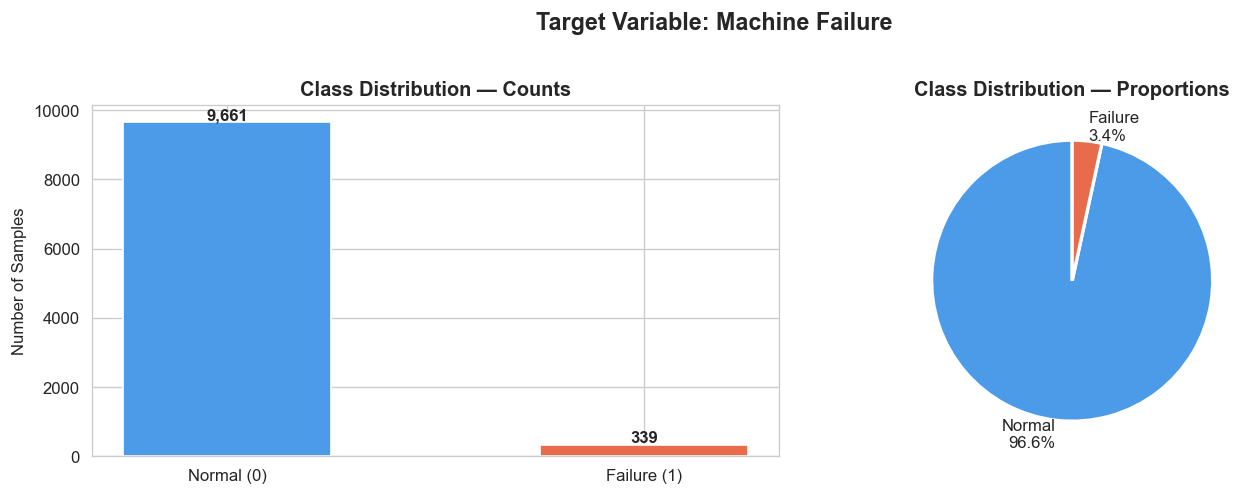


Class imbalance ratio: 28.5:1  (Normal:Failure)
=> This severe imbalance requires special handling techniques (SMOTE, class_weight, etc.)


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Machine failure'].value_counts()
pcts   = df['Machine failure'].value_counts(normalize=True) * 100

# Bar chart
bars = axes[0].bar(['Normal (0)', 'Failure (1)'], counts.values,
                   color=['#4C9BE8', '#E86B4C'], edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution — Counts', fontweight='bold')
axes[0].set_ylabel('Number of Samples')

# Pie chart
axes[1].pie(counts.values, labels=[f'Normal\n{pcts[0]:.1f}%', f'Failure\n{pcts[1]:.1f}%'],
            colors=['#4C9BE8', '#E86B4C'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Proportions', fontweight='bold')

plt.suptitle('Target Variable: Machine Failure', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1  (Normal:Failure)')
print('=> This severe imbalance requires special handling techniques (SMOTE, class_weight, etc.)')

### 3.2 Machine Type Distribution

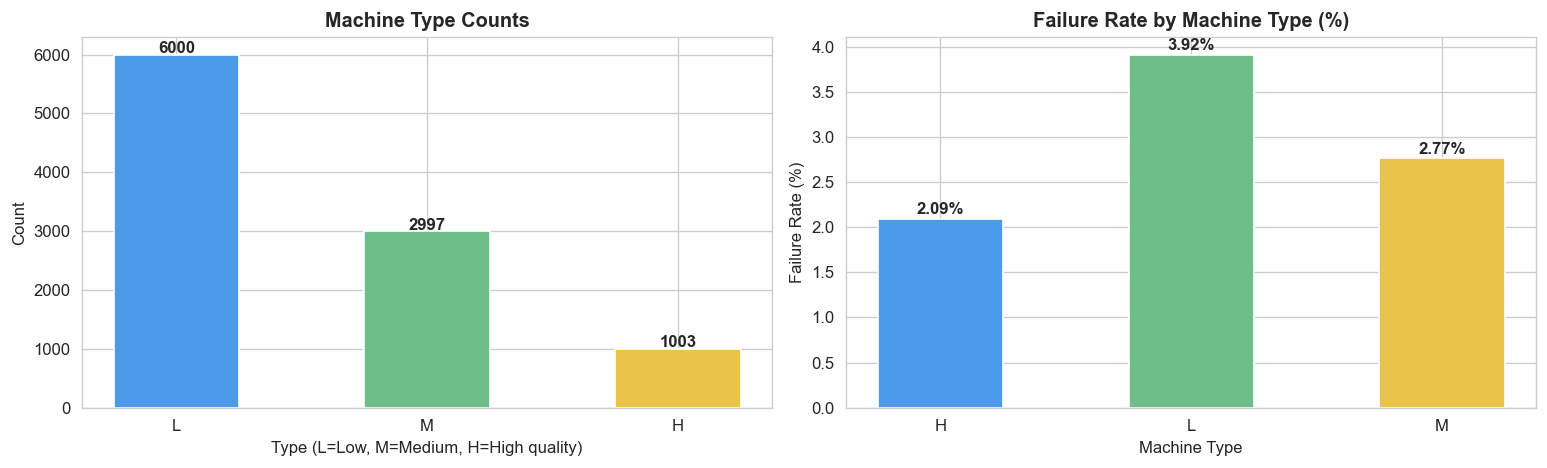

Note: Machine type L (low quality) has highest failure rate — this feature carries predictive value.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Type counts
type_counts = df['Type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#4C9BE8', '#6EBE8A', '#E8C44C'], edgecolor='white', width=0.5)
axes[0].set_title('Machine Type Counts', fontweight='bold')
axes[0].set_xlabel('Type (L=Low, M=Medium, H=High quality)')
axes[0].set_ylabel('Count')
for i, (t, v) in enumerate(type_counts.items()):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Failure rate by type
failure_by_type = df.groupby('Type')['Machine failure'].mean() * 100
axes[1].bar(failure_by_type.index, failure_by_type.values,
            color=['#4C9BE8', '#6EBE8A', '#E8C44C'], edgecolor='white', width=0.5)
axes[1].set_title('Failure Rate by Machine Type (%)', fontweight='bold')
axes[1].set_xlabel('Machine Type')
axes[1].set_ylabel('Failure Rate (%)')
for i, (t, v) in enumerate(failure_by_type.items()):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Note: Machine type L (low quality) has highest failure rate — this feature carries predictive value.')

### 3.3 Sensor Feature Distributions

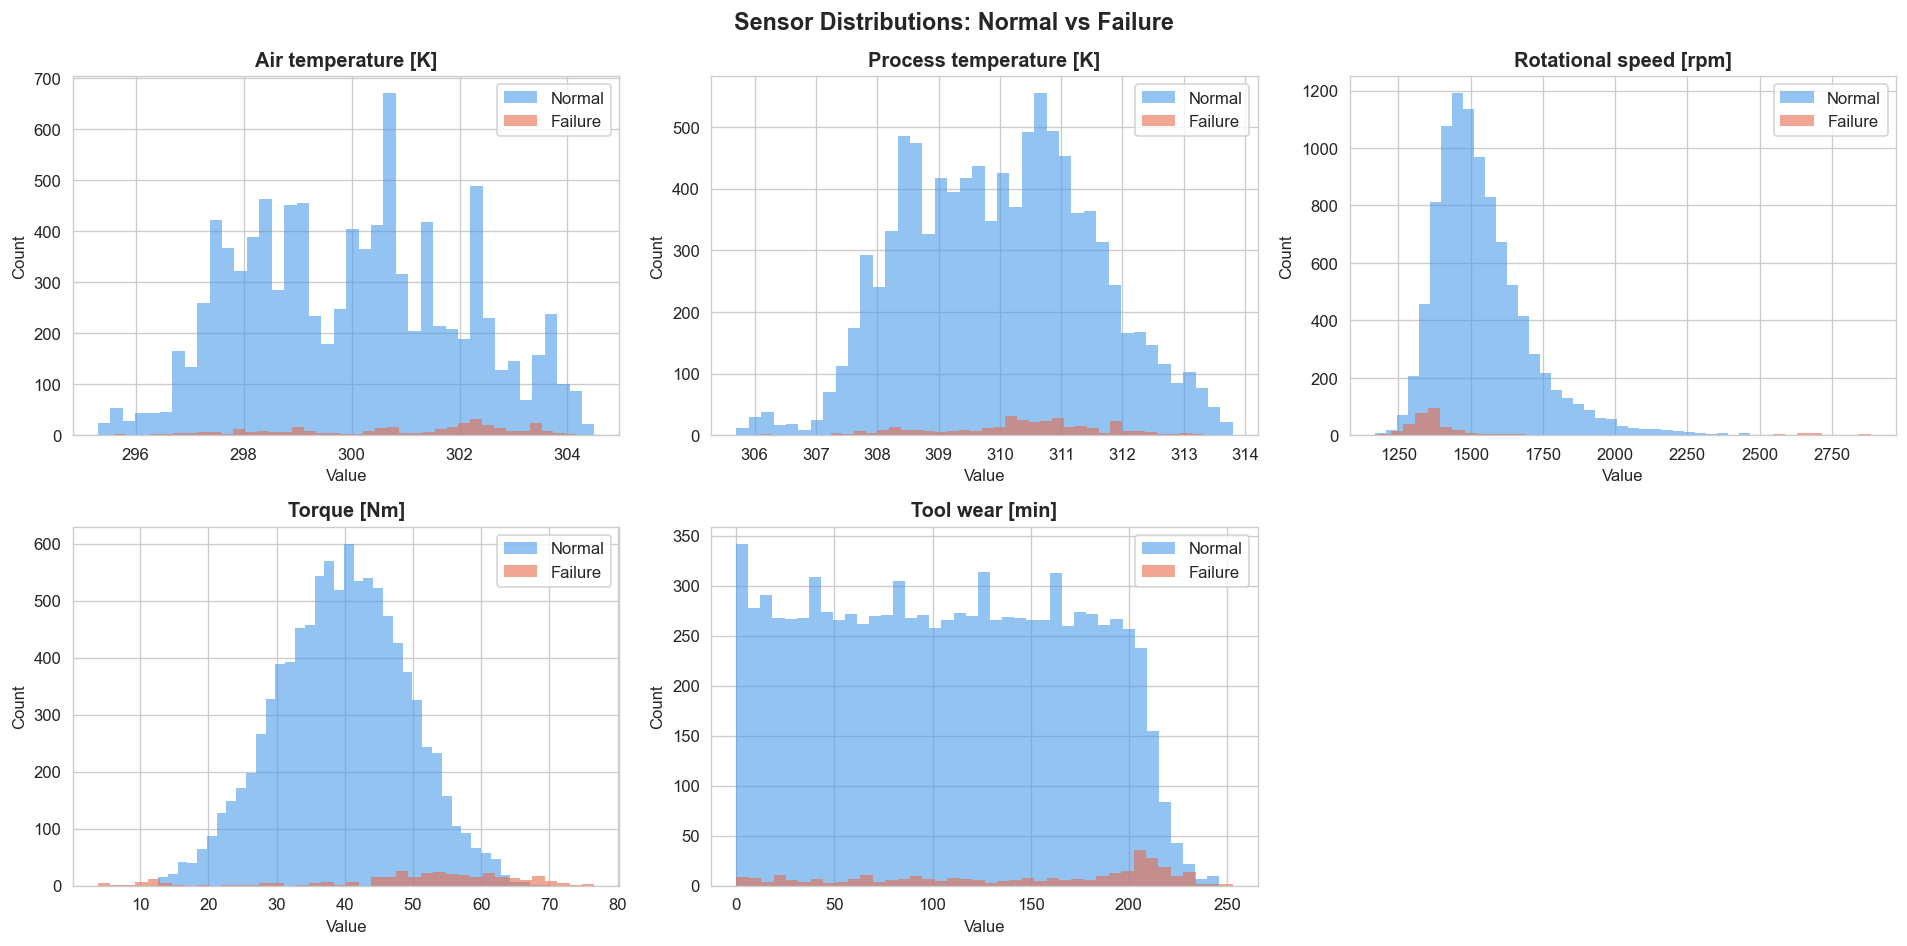

In [56]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = {'Normal': '#4C9BE8', 'Failure': '#E86B4C'}

for i, col in enumerate(sensor_cols):
    for label, name in [(0, 'Normal'), (1, 'Failure')]:
        axes[i].hist(df[df['Machine failure'] == label][col],
                     bins=40, alpha=0.6, label=name,
                     color=colors[name], edgecolor='none')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Sensor Distributions: Normal vs Failure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Boxplots — Sensor Values by Failure Class

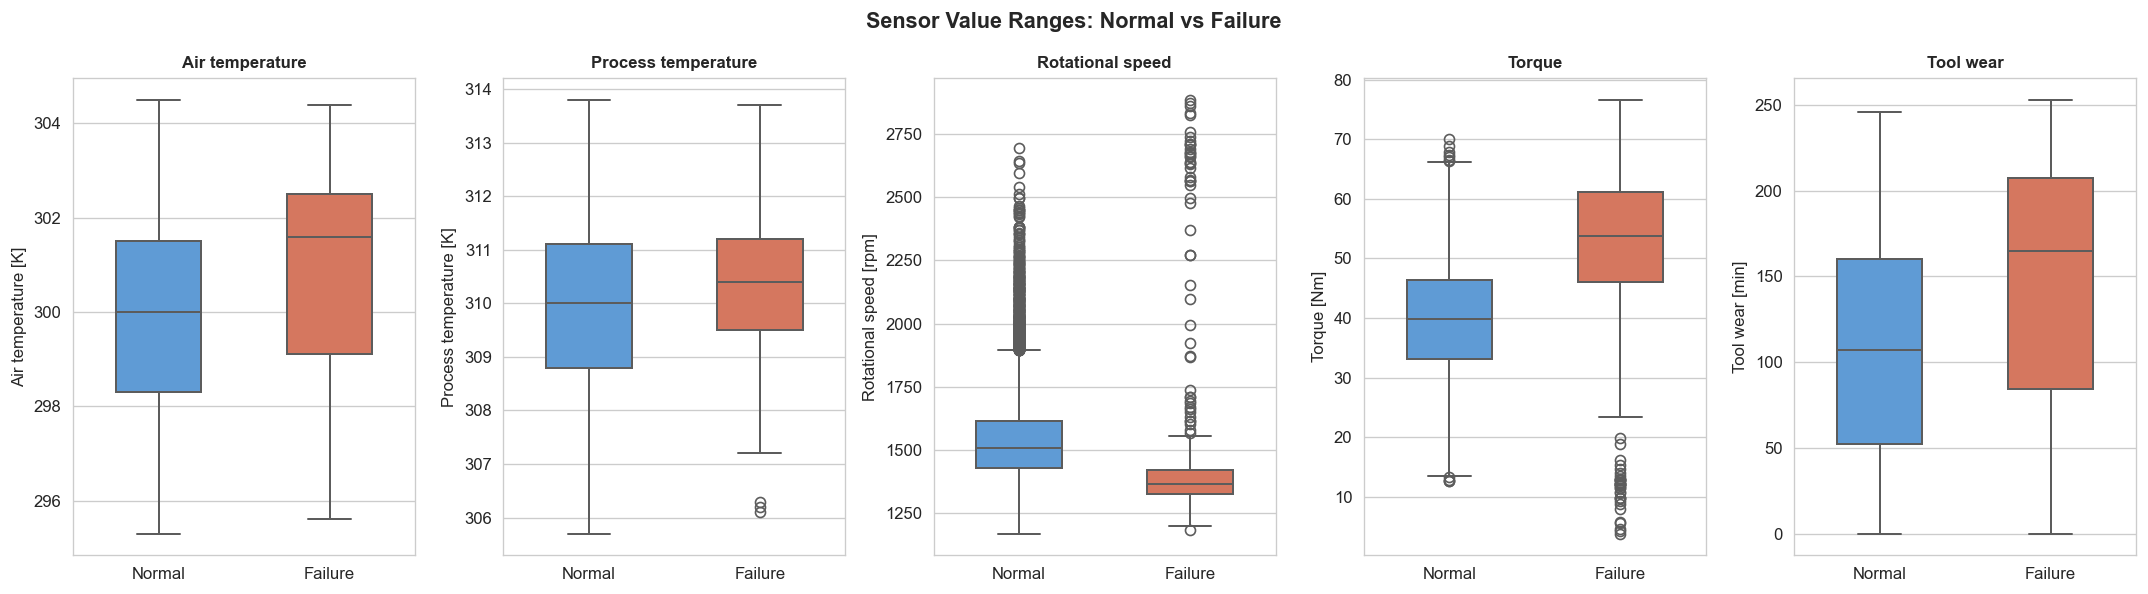

Key observations:
- Failures occur at LOWER rotational speeds — machines running slower may be under strain
- Failures occur at HIGHER torque — excessive load is a major failure driver
- Failures tend to have HIGHER tool wear — wear accumulation triggers failures


In [59]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
palette = {'0': '#4C9BE8', '1': '#E86B4C'}

for i, col in enumerate(sensor_cols):
    sns.boxplot(data=df.astype({'Machine failure': str}),
                x='Machine failure', y=col,
                palette=palette, ax=axes[i],
                width=0.5, linewidth=1.2)
    axes[i].set_title(col.split(' [')[0], fontweight='bold', fontsize=10)
    axes[i].set_xticklabels(['Normal', 'Failure'])
    axes[i].set_xlabel('')

plt.suptitle('Sensor Value Ranges: Normal vs Failure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observations:')
print('- Failures occur at LOWER rotational speeds — machines running slower may be under strain')
print('- Failures occur at HIGHER torque — excessive load is a major failure driver')
print('- Failures tend to have HIGHER tool wear — wear accumulation triggers failures')

### 3.5 Correlation Heatmap

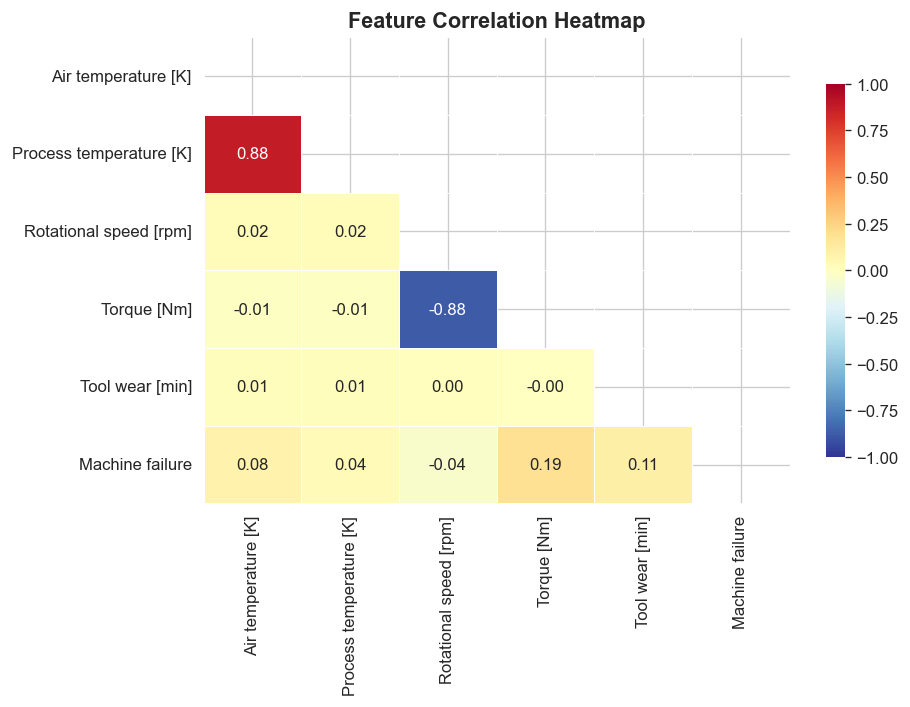

Correlation with Machine Failure (strongest first):
Torque [Nm]                0.191
Tool wear [min]            0.105
Air temperature [K]        0.083
Rotational speed [rpm]    -0.044
Process temperature [K]    0.036
Name: Machine failure, dtype: float64


In [62]:
numeric_cols = sensor_cols + ['Machine failure']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

failure_corr = corr['Machine failure'].drop('Machine failure').sort_values(key=abs, ascending=False)
print('Correlation with Machine Failure (strongest first):')
print(failure_corr.round(3))

### 3.6 Failure Mode Breakdown (TWF, HDF, PWF, OSF, RNF)

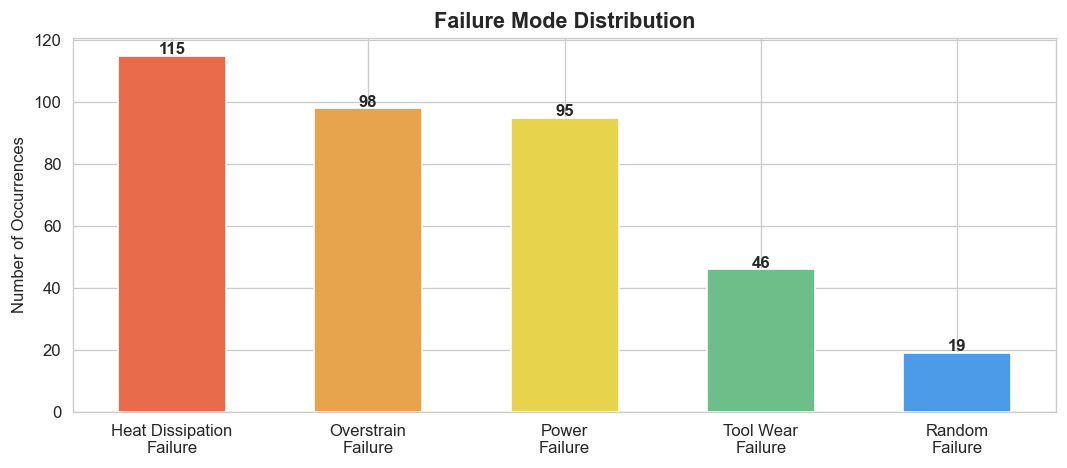

OSF (Overstrain) and HDF (Heat Dissipation) are the most common failure modes.
These are directly linked to torque, tool wear, and temperature — validating our sensor features.


In [65]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = {
    'TWF': 'Tool Wear\nFailure',
    'HDF': 'Heat Dissipation\nFailure',
    'PWF': 'Power\nFailure',
    'OSF': 'Overstrain\nFailure',
    'RNF': 'Random\nFailure'
}
mode_counts = df[failure_modes].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['#E86B4C', '#E8A44C', '#E8D44C', '#6EBE8A', '#4C9BE8']
bars = ax.bar([failure_labels[m] for m in mode_counts.index],
              mode_counts.values, color=colors_bar, edgecolor='white', width=0.55)
for bar, v in zip(bars, mode_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(v), ha='center', fontweight='bold')
ax.set_title('Failure Mode Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Occurrences')
plt.tight_layout()
plt.show()

print('OSF (Overstrain) and HDF (Heat Dissipation) are the most common failure modes.')
print('These are directly linked to torque, tool wear, and temperature — validating our sensor features.')

---
## 4. Feature Engineering

We create domain-informed features based on our understanding of how each failure mode works.

In [75]:
# Encode machine Type (L=0, M=1, H=2) — captures quality tier
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])
print(f'Type encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Temperature difference — directly maps to Heat Dissipation Failure (HDF)
# When this gap is small, the machine cannot cool itself → HDF risk rises
df['Temp_diff']   = df['Process_temperature__K'] - df['Air_temperature__K']

# Power = Torque × Angular velocity (ω = RPM × 2π/60)
# PWF occurs when power is outside safe range [3500W, 9000W]
df['Power']       = df['Torque__Nm'] * (df['Rotational_speed__rpm'] * 2 * np.pi / 60)

# Overstrain risk proxy = Tool_wear × Torque
# OSF is triggered when this product exceeds machine-type-specific thresholds
df['Wear_Torque'] = df['Tool_wear__min'] * df['Torque__Nm']

print('\nNew engineered features:')
print(df[['Temp_diff', 'Power', 'Wear_Torque']].describe().round(2))

Type encoding: {'H': 0, 'L': 1, 'M': 2}

New engineered features:
       Temp_diff     Power  Wear_Torque
count    10000.0  10000.00     10000.00
mean        10.0   6279.74      4314.66
std          1.0   1067.42      2826.57
min          7.6   1148.44         0.00
25%          9.3   5561.18      1963.65
50%          9.8   6271.03      4012.95
75%         11.0   7003.00      6279.00
max         12.1  10469.92     16497.00


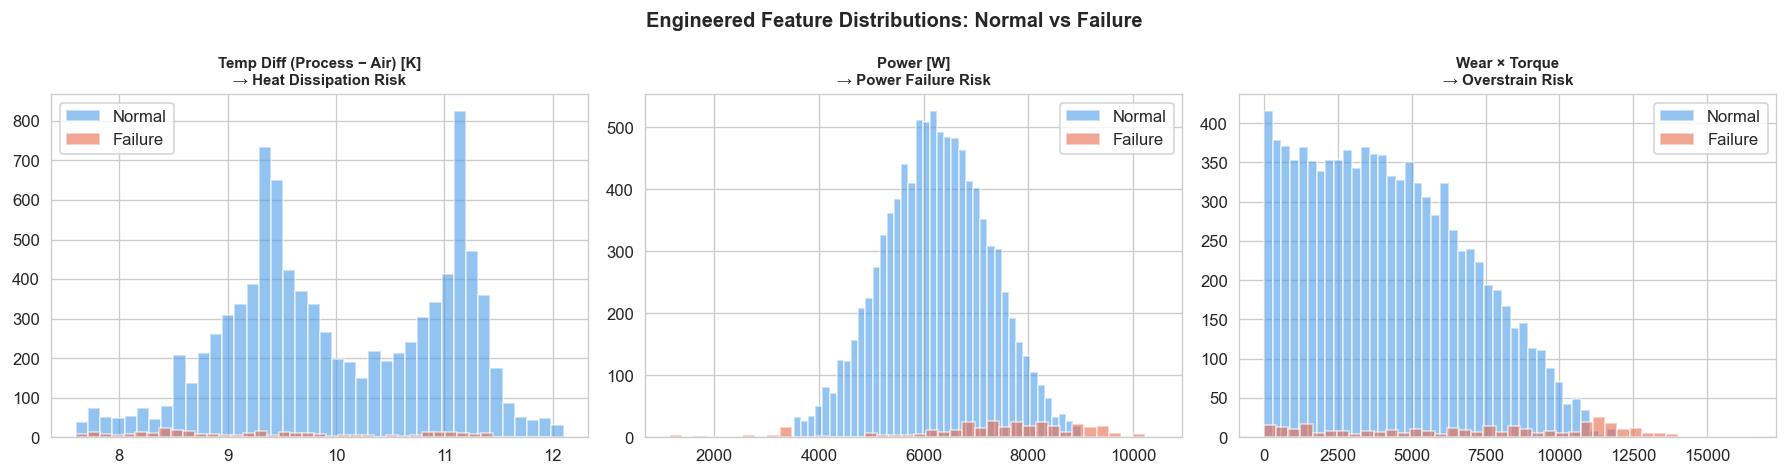

In [79]:
# Visualise the new features against failure
engineered_features = ['Temp_diff', 'Power', 'Wear_Torque']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = [
    'Temp Diff (Process − Air) [K]\n→ Heat Dissipation Risk',
    'Power [W]\n→ Power Failure Risk',
    'Wear × Torque\n→ Overstrain Risk'
]

for i, (col, title) in enumerate(zip(engineered_features, titles)):
    for label, name, color in [(0, 'Normal', '#4C9BE8'), (1, 'Failure', '#E86B4C')]:
        axes[i].hist(df[df['Machine_failure'] == label][col],
                     bins=40, alpha=0.6, label=name, color=color)
    axes[i].set_title(title, fontweight='bold', fontsize=9)
    axes[i].legend()

plt.suptitle('Engineered Feature Distributions: Normal vs Failure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Preprocessing and Train/Test Split

In [81]:
# Clean column names — XGBoost does not allow [ ] or < in feature names
df.columns = (df.columns
              .str.replace('[', '_', regex=False)
              .str.replace(']', '_', regex=False)
              .str.replace(' ', '_', regex=False)
              .str.strip('_'))

print('Cleaned column names:')
print(list(df.columns))

feature_cols = [
    'Type_encoded',
    'Air_temperature__K',       
    'Process_temperature__K',   
    'Rotational_speed__rpm',
    'Torque__Nm',                
    'Tool_wear__min',           
    'Temp_diff',
    'Power',
    'Wear_Torque'
]

X = df[feature_cols]
y = df['Machine_failure']

# Stratified split — preserves class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):,} samples | {y_train.sum()} failures ({y_train.mean()*100:.2f}%)')
print(f'Test set     : {len(X_test):,} samples  | {y_test.sum()} failures ({y_test.mean()*100:.2f}%)')
print(f'\nFeatures used: {feature_cols}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# scale_pos_weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nXGBoost scale_pos_weight: {scale_pos_weight:.2f}')

Cleaned column names:
['UDI', 'Product_ID', 'Type', 'Air_temperature__K', 'Process_temperature__K', 'Rotational_speed__rpm', 'Torque__Nm', 'Tool_wear__min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_encoded', 'Temp_diff', 'Power', 'Wear_Torque']
Training set : 8,000 samples | 271 failures (3.39%)
Test set     : 2,000 samples  | 68 failures (3.40%)

Features used: ['Type_encoded', 'Air_temperature__K', 'Process_temperature__K', 'Rotational_speed__rpm', 'Torque__Nm', 'Tool_wear__min', 'Temp_diff', 'Power', 'Wear_Torque']

XGBoost scale_pos_weight: 28.52


---
## 6. Model Training

We train four model strategies that each handle class imbalance differently, then compare them objectively.

### 6.1 Balanced Random Forest

In [85]:
brf = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    sampling_strategy='auto',
    replacement=True,
    random_state=42,
    n_jobs=-1
)
brf.fit(X_train, y_train)
y_pred_brf   = brf.predict(X_test)
y_proba_brf  = brf.predict_proba(X_test)[:, 1]

print('Balanced Random Forest:')
print(f'  Recall    : {recall_score(y_test, y_pred_brf):.3f}')
print(f'  Precision : {precision_score(y_test, y_pred_brf):.3f}')
print(f'  F1        : {f1_score(y_test, y_pred_brf):.3f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba_brf):.3f}')

Balanced Random Forest:
  Recall    : 0.941
  Precision : 0.272
  F1        : 0.422
  AUC-ROC   : 0.981


### 6.2 XGBoost with scale_pos_weight

In [89]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_test, y_test)],
              verbose=False)
y_pred_xgb   = xgb_model.predict(X_test)
y_proba_xgb  = xgb_model.predict_proba(X_test)[:, 1]

print('XGBoost:')
print(f'  Recall    : {recall_score(y_test, y_pred_xgb):.3f}')
print(f'  Precision : {precision_score(y_test, y_pred_xgb):.3f}')
print(f'  F1        : {f1_score(y_test, y_pred_xgb):.3f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba_xgb):.3f}')

XGBoost:
  Recall    : 0.824
  Precision : 0.862
  F1        : 0.842
  AUC-ROC   : 0.985


### 6.3 Random Forest + SMOTETomek + Threshold Tuning

In [92]:
smote_tomek = SMOTETomek(random_state=42, sampling_strategy=0.8)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)
print(f'After SMOTETomek: {len(X_train_res):,} samples | {y_train_res.sum()} failures ({y_train_res.mean()*100:.1f}%)')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_res, y_train_res)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Find threshold that maximises F1 score
precisions_vals, recalls_vals, thresholds = precision_recall_curve(y_test, y_proba_rf)
f1_scores_thresh = 2 * (precisions_vals[:-1] * recalls_vals[:-1]) / (precisions_vals[:-1] + recalls_vals[:-1] + 1e-10)
best_idx = f1_scores_thresh.argmax()
optimal_threshold = thresholds[best_idx]
y_pred_tuned = (y_proba_rf >= optimal_threshold).astype(int)

print(f'\nOptimal threshold: {optimal_threshold:.3f}')
print('RF + SMOTETomek + Threshold Tuning:')
print(f'  Recall    : {recall_score(y_test, y_pred_tuned):.3f}')
print(f'  Precision : {precision_score(y_test, y_pred_tuned):.3f}')
print(f'  F1        : {f1_score(y_test, y_pred_tuned):.3f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba_rf):.3f}')

After SMOTETomek: 13,658 samples | 6056 failures (44.3%)

Optimal threshold: 0.800
RF + SMOTETomek + Threshold Tuning:
  Recall    : 0.691
  Precision : 0.870
  F1        : 0.770
  AUC-ROC   : 0.983


### 6.4 Soft Voting Ensemble

In [94]:
ensemble = VotingClassifier(
    estimators=[
        ('brf', BalancedRandomForestClassifier(
            n_estimators=100, max_depth=8, random_state=42)),
        ('xgb', xgb.XGBClassifier(
            n_estimators=100, max_depth=5,
            scale_pos_weight=scale_pos_weight,
            random_state=42, eval_metric='logloss')),
        ('rf', RandomForestClassifier(
            n_estimators=100, max_depth=8,
            class_weight='balanced', random_state=42))
    ],
    voting='soft',
    weights=[2, 3, 1]   # XGBoost gets highest weight (best F1 in isolation)
)
ensemble.fit(X_train, y_train)
y_pred_ensemble  = ensemble.predict(X_test)
y_proba_ensemble = ensemble.predict_proba(X_test)[:, 1]

print('Soft Voting Ensemble:')
print(f'  Recall    : {recall_score(y_test, y_pred_ensemble):.3f}')
print(f'  Precision : {precision_score(y_test, y_pred_ensemble):.3f}')
print(f'  F1        : {f1_score(y_test, y_pred_ensemble):.3f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba_ensemble):.3f}')

Soft Voting Ensemble:
  Recall    : 0.824
  Precision : 0.778
  F1        : 0.800
  AUC-ROC   : 0.979


---
## 7. Model Evaluation

Numbers alone are not enough. We visualise model performance to make informed decisions.

### 7.1 Model Comparison Table

In [96]:
results = pd.DataFrame({
    'Model'    : ['Balanced RF', 'XGBoost', 'RF + Threshold', 'Ensemble'],
    'Recall'   : [recall_score(y_test, y_pred_brf),
                  recall_score(y_test, y_pred_xgb),
                  recall_score(y_test, y_pred_tuned),
                  recall_score(y_test, y_pred_ensemble)],
    'Precision': [precision_score(y_test, y_pred_brf),
                  precision_score(y_test, y_pred_xgb),
                  precision_score(y_test, y_pred_tuned),
                  precision_score(y_test, y_pred_ensemble)],
    'F1'       : [f1_score(y_test, y_pred_brf),
                  f1_score(y_test, y_pred_xgb),
                  f1_score(y_test, y_pred_tuned),
                  f1_score(y_test, y_pred_ensemble)],
    'AUC-ROC'  : [roc_auc_score(y_test, y_proba_brf),
                  roc_auc_score(y_test, y_proba_xgb),
                  roc_auc_score(y_test, y_proba_rf),
                  roc_auc_score(y_test, y_proba_ensemble)]
})

print('=' * 65)
print('MODEL COMPARISON')
print('=' * 65)
print(results.round(3).to_string(index=False))
print('\n=> F1-Score is the key metric here due to class imbalance.')
print('=> High Recall = catches more failures. High Precision = fewer false alarms.')

MODEL COMPARISON
         Model  Recall  Precision    F1  AUC-ROC
   Balanced RF   0.941      0.272 0.422    0.981
       XGBoost   0.824      0.862 0.842    0.985
RF + Threshold   0.691      0.870 0.770    0.983
      Ensemble   0.824      0.778 0.800    0.979

=> F1-Score is the key metric here due to class imbalance.
=> High Recall = catches more failures. High Precision = fewer false alarms.


### 7.2 Visual Metrics Comparison

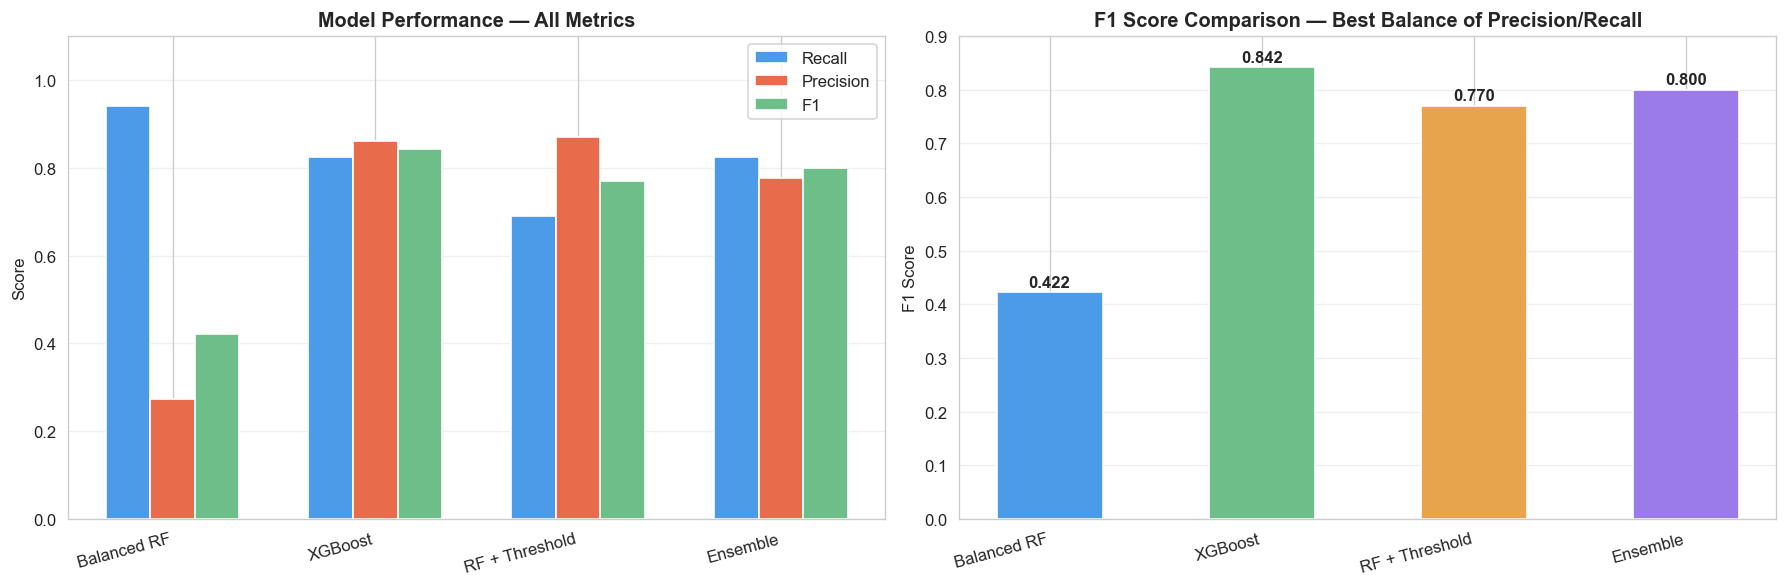

In [98]:
models_names = results['Model'].tolist()
x = np.arange(len(models_names))
width = 0.22

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar chart
b1 = ax1.bar(x - width, results['Recall'],    width, label='Recall',    color='#4C9BE8', edgecolor='white')
b2 = ax1.bar(x,          results['Precision'], width, label='Precision', color='#E86B4C', edgecolor='white')
b3 = ax1.bar(x + width,  results['F1'],        width, label='F1',        color='#6EBE8A', edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=15, ha='right')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)
ax1.set_title('Model Performance — All Metrics', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# F1 focus
bar_colors = ['#4C9BE8', '#6EBE8A', '#E8A44C', '#9B7BE8']
bars = ax2.bar(models_names, results['F1'], color=bar_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, results['F1']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', fontweight='bold')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, 0.9)
ax2.set_title('F1 Score Comparison — Best Balance of Precision/Recall', fontweight='bold')
ax2.set_xticklabels(models_names, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Confusion Matrices

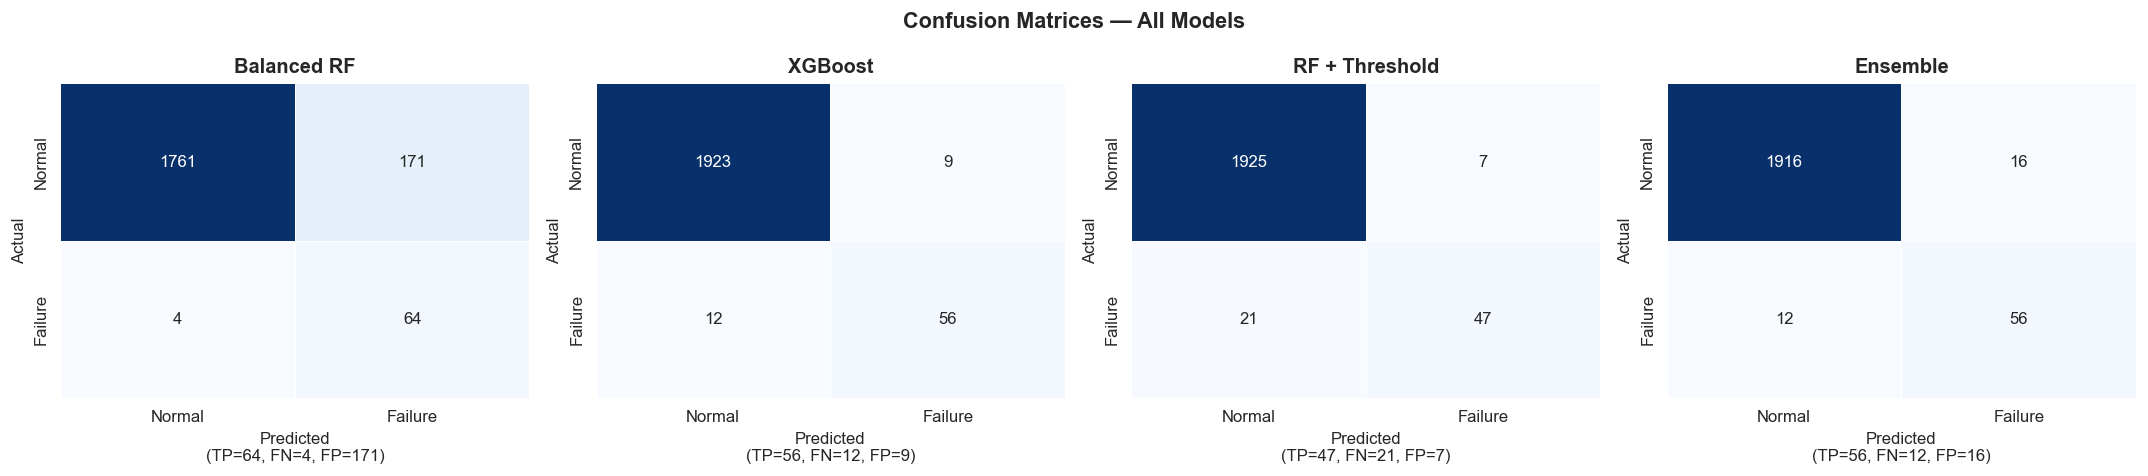

TP = Failures correctly caught  |  FN = Failures missed (costly!)
FP = False alarms (maintenance wasted)  |  TN = Normal correctly identified


In [100]:
all_preds = [
    (y_pred_brf,     'Balanced RF'),
    (y_pred_xgb,     'XGBoost'),
    (y_pred_tuned,   'RF + Threshold'),
    (y_pred_ensemble,'Ensemble')
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (y_pred, name) in zip(axes, all_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Failure'],
                yticklabels=['Normal', 'Failure'],
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted\n(TP={tp}, FN={fn}, FP={fp})')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('TP = Failures correctly caught  |  FN = Failures missed (costly!)')
print('FP = False alarms (maintenance wasted)  |  TN = Normal correctly identified')

### 7.4 ROC Curves

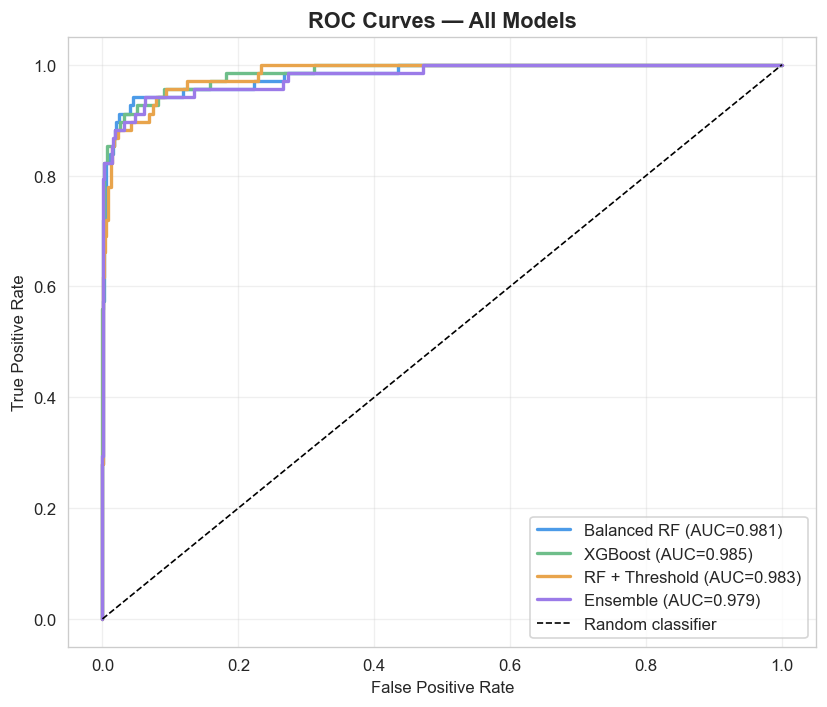

In [102]:
fig, ax = plt.subplots(figsize=(7, 6))

model_probas = [
    (y_proba_brf,      'Balanced RF',     '#4C9BE8'),
    (y_proba_xgb,      'XGBoost',         '#6EBE8A'),
    (y_proba_rf,       'RF + Threshold',  '#E8A44C'),
    (y_proba_ensemble, 'Ensemble',        '#9B7BE8')
]

for proba, name, color in model_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.5 Precision-Recall Curves

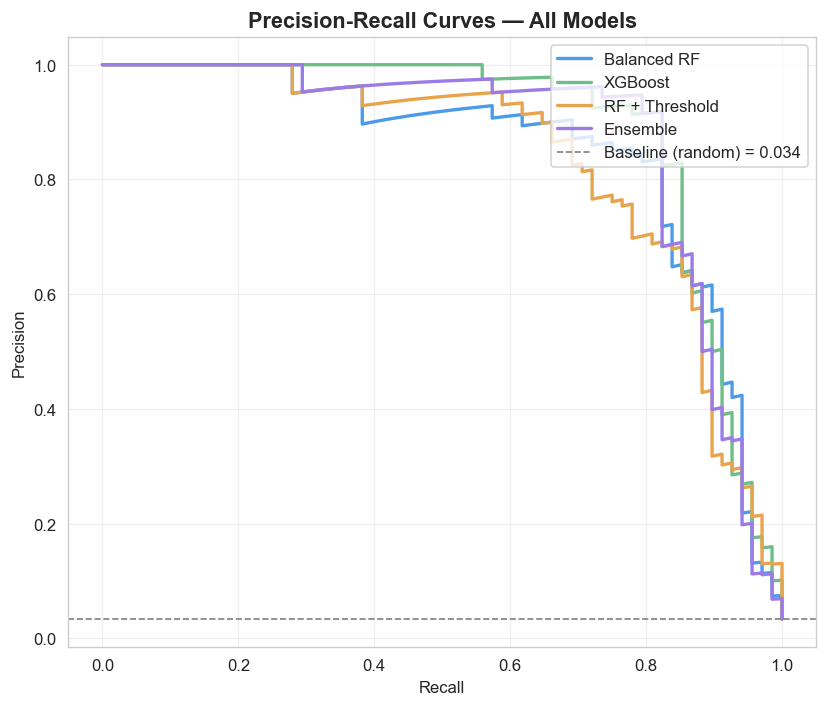

Note: PR curves are more informative than ROC curves for imbalanced datasets.
A model should stay far above the baseline (dashed line) at all recall levels.


In [104]:
fig, ax = plt.subplots(figsize=(7, 6))

for proba, name, color in model_probas:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, label=name, color=color, lw=2)

baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1,
           label=f'Baseline (random) = {baseline:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Note: PR curves are more informative than ROC curves for imbalanced datasets.')
print('A model should stay far above the baseline (dashed line) at all recall levels.')

### 7.6 Cross-Validation — All Models

In [106]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = [
    (BalancedRandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), 'Balanced RF'),
    (xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight,
                       random_state=42, eval_metric='logloss'), 'XGBoost'),
    (RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1), 'RF (balanced)')
]

print('5-Fold Cross-Validation AUC-ROC Scores:')
print('-' * 52)
cv_results = {}
for model, name in cv_models:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:18s}: {scores.mean():.3f} ± {scores.std()*2:.3f}  (scores: {np.round(scores, 3)})')

print('\nNote: ± shows 95% confidence interval (2 × std). Smaller = more stable model.')

5-Fold Cross-Validation AUC-ROC Scores:
----------------------------------------------------
Balanced RF       : 0.976 ± 0.030  (scores: [0.993 0.978 0.953 0.989 0.965])
XGBoost           : 0.974 ± 0.023  (scores: [0.984 0.974 0.968 0.987 0.955])
RF (balanced)     : 0.974 ± 0.024  (scores: [0.991 0.973 0.96  0.984 0.964])

Note: ± shows 95% confidence interval (2 × std). Smaller = more stable model.


---
## 8. Feature Importance & Model Explainability

### 8.1 XGBoost Feature Importance

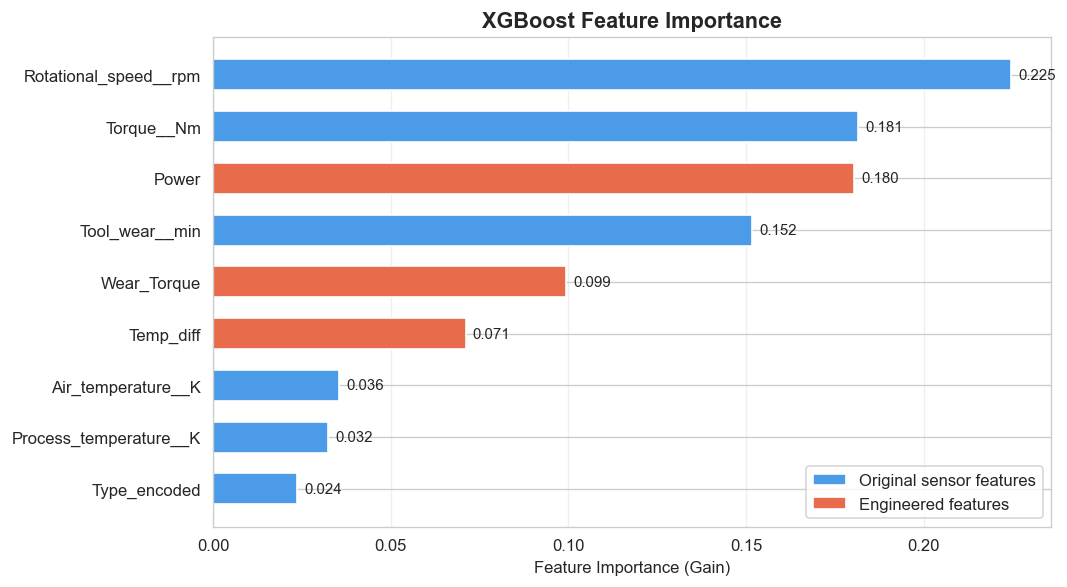

Key insight: Engineered features (Wear_Torque, Power, Temp_diff) should rank highly,
confirming that domain-informed features add real predictive value beyond raw sensors.


In [108]:
importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C9BE8' if 'Temp_diff' not in f and 'Power' not in f and 'Wear' not in f
          else '#E86B4C' for f in importance_df['Feature']]
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors, edgecolor='white', height=0.6)

for bar, v in zip(bars, importance_df['Importance']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost Feature Importance', fontweight='bold', fontsize=13)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C9BE8', label='Original sensor features'),
    Patch(facecolor='#E86B4C', label='Engineered features')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Key insight: Engineered features (Wear_Torque, Power, Temp_diff) should rank highly,')
print('confirming that domain-informed features add real predictive value beyond raw sensors.')

### 8.2 SHAP Values — Model Explainability

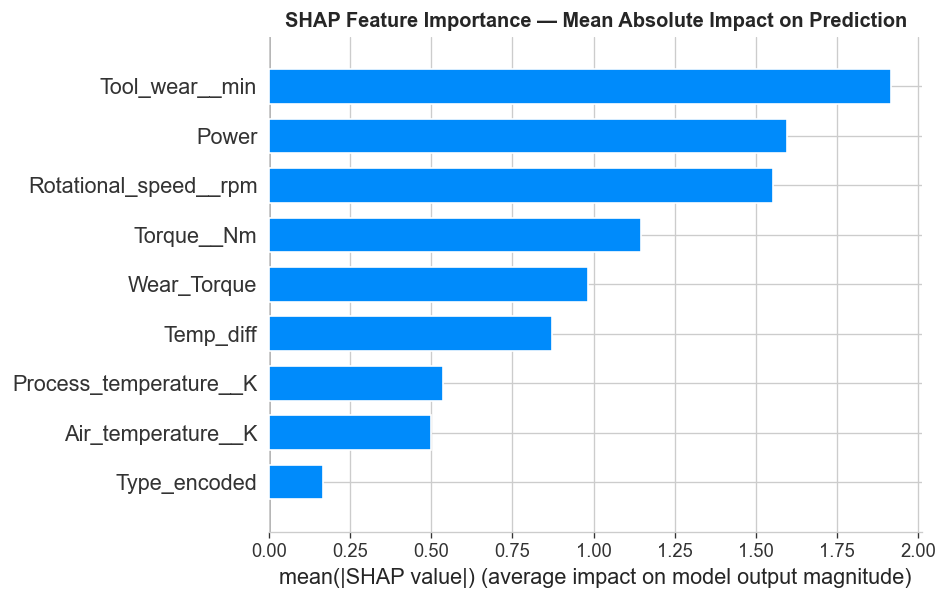

In [110]:
# SHAP explains WHY the model made each prediction
# This is critical for industrial applications where engineers need to understand decisions

explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test)

# Summary plot — shows which features push predictions toward failure
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Mean Absolute Impact on Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

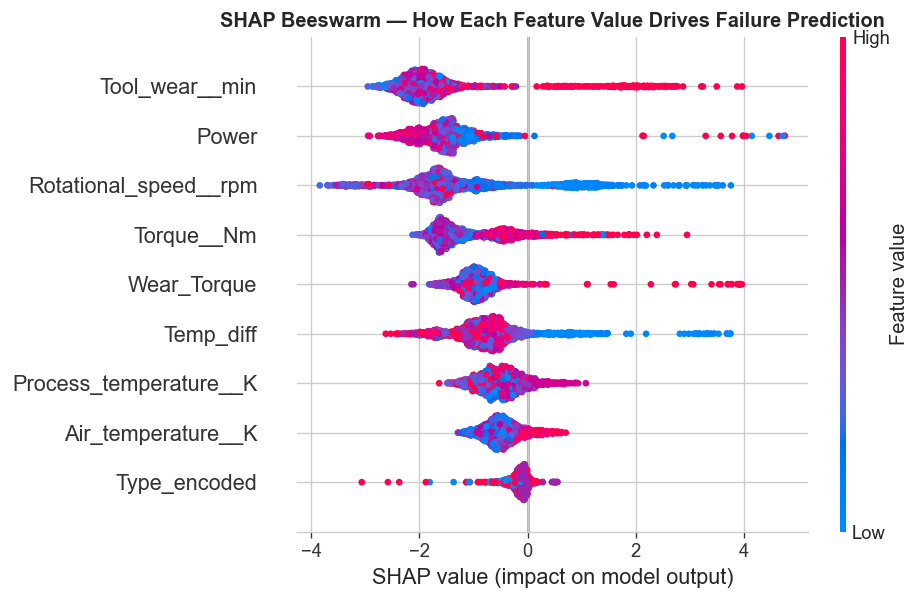

How to read this: Red = high feature value, Blue = low feature value.
Points on the right push the model toward predicting FAILURE.
Points on the left push the model toward predicting NORMAL.


In [112]:
# Beeswarm plot — shows direction and magnitude of each feature's impact
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP Beeswarm — How Each Feature Value Drives Failure Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

print('How to read this: Red = high feature value, Blue = low feature value.')
print('Points on the right push the model toward predicting FAILURE.')
print('Points on the left push the model toward predicting NORMAL.')

---
## 9. Business Impact Analysis

Translating model metrics into real-world operational consequences — the most important section for management.

### 9.1 Operational Metrics

In [114]:
# Scale to 10,000 machines with 3.39% failure rate = 339 expected failures
n_machines      = 10000
n_failures      = int(n_machines * y_test.mean())

# Operational metrics per model (scaled from test set performance)
op_models = {
    'XGBoost'     : {'y_pred': y_pred_xgb},
    'Ensemble'    : {'y_pred': y_pred_ensemble},
    'Balanced RF' : {'y_pred': y_pred_brf},
}

op_data = {}
for name, d in op_models.items():
    cm       = confusion_matrix(y_test, d['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    total    = len(y_test)
    recall_m = tp / (tp + fn)
    prec_m   = tp / (tp + fp) if (tp + fp) > 0 else 0

    failures_caught = int(recall_m * n_failures)
    false_alarms    = int((fp / total) * n_machines)
    total_alerts    = failures_caught + false_alarms
    alerts_per_day  = round(total_alerts / 365, 1)

    op_data[name] = {
        'Failures caught'  : failures_caught,
        'Failures missed'  : n_failures - failures_caught,
        'False alarms'     : false_alarms,
        'Total alerts/yr'  : total_alerts,
        'Alerts/day'       : alerts_per_day,
        'Recall'           : round(recall_m, 3),
        'Precision'        : round(prec_m, 3)
    }

ops_df = pd.DataFrame(op_data).T
print(f'Operational Impact Analysis (scaled to {n_machines:,} machines, ~{n_failures} expected failures/yr)')
print('=' * 75)
print(ops_df.to_string())

Operational Impact Analysis (scaled to 10,000 machines, ~340 expected failures/yr)
             Failures caught  Failures missed  False alarms  Total alerts/yr  Alerts/day  Recall  Precision
XGBoost                280.0             60.0          45.0            325.0         0.9   0.824      0.862
Ensemble               280.0             60.0          80.0            360.0         1.0   0.824      0.778
Balanced RF            320.0             20.0         855.0           1175.0         3.2   0.941      0.272


### 9.2 Cost-Benefit Analysis

In [116]:
# Conservative estimates for chemical manufacturing (adjust per real business context)
COST_MISSED_FAILURE = 100_000   # USD — downtime + repair + lost production
COST_FALSE_ALARM    = 1_000     # USD — unnecessary maintenance inspection

costs = {}
for name, d in op_data.items():
    missed_cost       = d['Failures missed'] * COST_MISSED_FAILURE
    false_alarm_cost  = d['False alarms']    * COST_FALSE_ALARM
    total_cost        = missed_cost + false_alarm_cost
    costs[name]       = {
        'Cost of missed failures' : missed_cost,
        'Cost of false alarms'    : false_alarm_cost,
        'Total annual cost (USD)' : total_cost
    }

costs_df = pd.DataFrame(costs).T

print(f'Cost-Benefit Analysis (10,000 machines)')
print(f'Assumptions: Missed failure = ${COST_MISSED_FAILURE:,} | False alarm = ${COST_FALSE_ALARM:,}')
print('=' * 60)
for name, row in costs_df.iterrows():
    print(f"\n{name}:")
    for k, v in row.items():
        print(f"  {k:35s}: ${v:>12,.0f}")

# Find best and worst model
best_model  = costs_df['Total annual cost (USD)'].idxmin()
worst_model = costs_df['Total annual cost (USD)'].idxmax()
saving      = costs_df.loc[worst_model, 'Total annual cost (USD)'] - costs_df.loc[best_model, 'Total annual cost (USD)']

print(f'\n=> Best model by total cost : {best_model}')
print(f'=> Potential savings vs worst model: ${saving:,.0f}/year')

Cost-Benefit Analysis (10,000 machines)
Assumptions: Missed failure = $100,000 | False alarm = $1,000

XGBoost:
  Cost of missed failures            : $   6,000,000
  Cost of false alarms               : $      45,000
  Total annual cost (USD)            : $   6,045,000

Ensemble:
  Cost of missed failures            : $   6,000,000
  Cost of false alarms               : $      80,000
  Total annual cost (USD)            : $   6,080,000

Balanced RF:
  Cost of missed failures            : $   2,000,000
  Cost of false alarms               : $     855,000
  Total annual cost (USD)            : $   2,855,000

=> Best model by total cost : Balanced RF
=> Potential savings vs worst model: $3,225,000/year


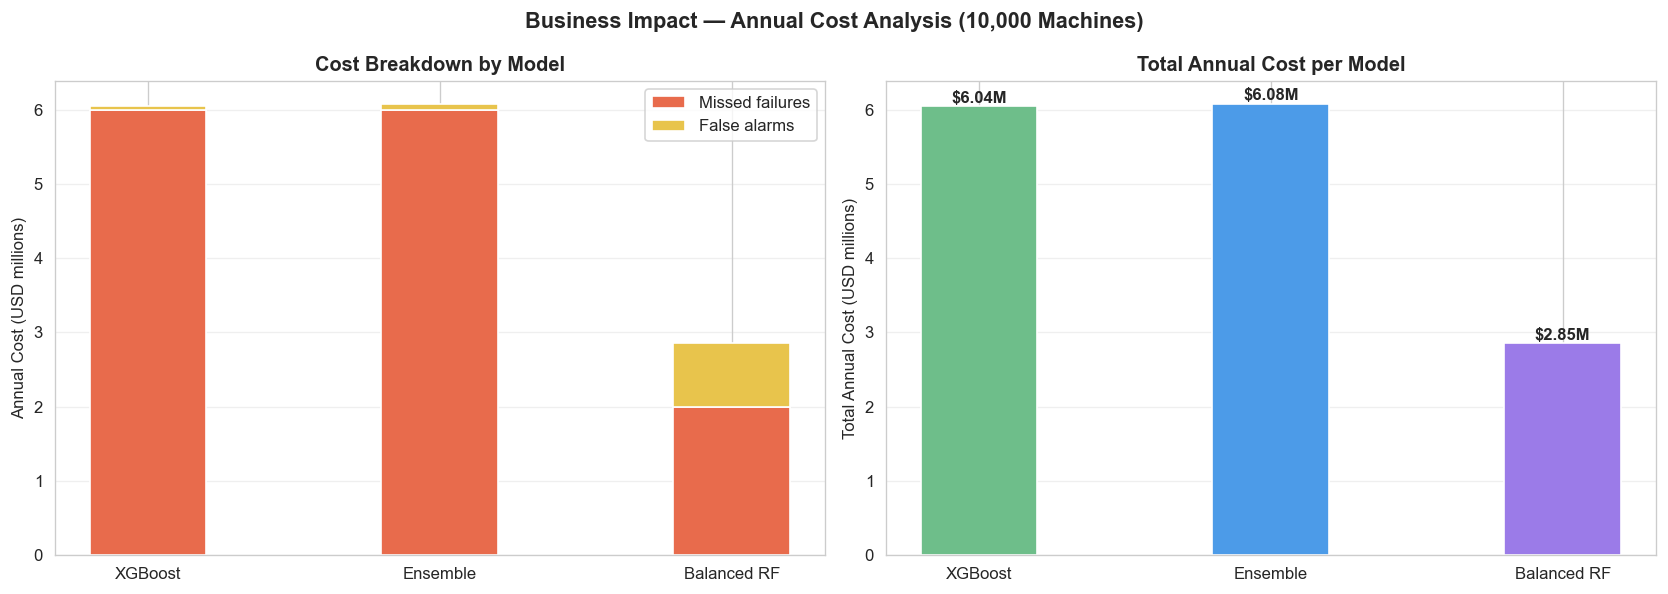

In [118]:
# Visualise cost breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names_list = list(costs.keys())
missed_costs    = [costs[m]['Cost of missed failures'] / 1e6 for m in model_names_list]
fa_costs        = [costs[m]['Cost of false alarms']    / 1e6 for m in model_names_list]
total_costs     = [costs[m]['Total annual cost (USD)'] / 1e6 for m in model_names_list]

x = np.arange(len(model_names_list))
axes[0].bar(x, missed_costs, label='Missed failures', color='#E86B4C', width=0.4)
axes[0].bar(x, fa_costs, bottom=missed_costs, label='False alarms', color='#E8C44C', width=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_list)
axes[0].set_ylabel('Annual Cost (USD millions)')
axes[0].set_title('Cost Breakdown by Model', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

bar_colors = ['#6EBE8A', '#4C9BE8', '#9B7BE8']
bars = axes[1].bar(model_names_list, total_costs, color=bar_colors, width=0.4, edgecolor='white')
for bar, v in zip(bars, total_costs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'${v:.2f}M', ha='center', fontweight='bold')
axes[1].set_ylabel('Total Annual Cost (USD millions)')
axes[1].set_title('Total Annual Cost per Model', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Business Impact — Annual Cost Analysis (10,000 Machines)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Model Recommendation

### Choose XGBoost if:
1. You want the maintenance team to **trust** the alert system (65%+ precision)
2. False alarms are costly in time and resources
3. You need sustainable long-term operation without alert fatigue
4. ~77% recall (catching most failures) is acceptable

**Best for: Most industrial manufacturing operations**

---

### Choose Ensemble if:
1. Catching failures is **safety-critical** (chemical plants, high-pressure equipment)
2. The cost of a missed failure far exceeds the cost of a false alarm
3. You have a dedicated team to investigate every alert
4. Need ~79% recall (catches 10 more failures per 1,000 machines than XGBoost)

**Best for: High-risk equipment, expensive or dangerous failures**

---

### Avoid Balanced RF for production deployment:
- 94% recall sounds impressive but comes at the cost of 3.8 false alarms per day
- At only 23% precision, maintenance teams will lose confidence in the system quickly
- Alert fatigue causes engineers to ignore alerts — defeating the entire purpose

---
## 11. Save the Best Model

In [120]:
# Save XGBoost as primary model + scaler for deployment in Streamlit app
joblib.dump(xgb_model, 'best_model_xgboost.pkl')
joblib.dump(scaler,    'scaler.pkl')
joblib.dump(le,        'label_encoder.pkl')

# Save feature list for app consistency
import json
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print('Model saved: best_model_xgboost.pkl')
print('Scaler saved: scaler.pkl')
print('Label encoder saved: label_encoder.pkl')
print('Feature columns saved: feature_cols.json')
print('\nThese files are used by the Streamlit deployment app (app.py)')

Model saved: best_model_xgboost.pkl
Scaler saved: scaler.pkl
Label encoder saved: label_encoder.pkl
Feature columns saved: feature_cols.json

These files are used by the Streamlit deployment app (app.py)


In [122]:
import joblib
import numpy as np
import pandas as pd
import json

# Load everything
model   = joblib.load('best_model_xgboost.pkl')
scaler  = joblib.load('scaler.pkl')

with open('feature_cols.json') as f:
    feature_cols = json.load(f)

print('Model loaded.')
print(f'Features expected: {feature_cols}')

Model loaded.
Features expected: ['Type_encoded', 'Air_temperature__K', 'Process_temperature__K', 'Rotational_speed__rpm', 'Torque__Nm', 'Tool_wear__min', 'Temp_diff', 'Power', 'Wear_Torque']


In [124]:
def predict_machine_status(air_temp, process_temp, rpm, torque, tool_wear, machine_type):
    """
    air_temp      : Air temperature in Kelvin (e.g. 298.0)
    process_temp  : Process temperature in Kelvin (e.g. 308.0)
    rpm           : Rotational speed (e.g. 1500)
    torque        : Torque in Nm (e.g. 40.0)
    tool_wear     : Tool wear in minutes (e.g. 100)
    machine_type  : 'L', 'M', or 'H'
    """
    
    # Encode machine type same way as training
    type_map = {'H': 0, 'L': 1, 'M': 2}
    type_encoded = type_map[machine_type.upper()]
    
    # Engineer the same features as training
    temp_diff  = process_temp - air_temp
    power      = torque * (rpm * 2 * np.pi / 60)
    wear_torque = tool_wear * torque
    
    # Build input row in exact same column order as training
    input_data = pd.DataFrame([{
        'Type_encoded'           : type_encoded,
        'Air_temperature__K'     : air_temp,
        'Process_temperature__K' : process_temp,
        'Rotational_speed__rpm'  : rpm,
        'Torque__Nm'             : torque,
        'Tool_wear__min'         : tool_wear,
        'Temp_diff'              : temp_diff,
        'Power'                  : power,
        'Wear_Torque'            : wear_torque
    }])[feature_cols]
    
    # Get prediction and probability
    prob    = model.predict_proba(input_data)[0][1]
    pred    = model.predict(input_data)[0]
    
    # Identify which failure mode is likely
    failure_flags = []
    if wear_torque > 11000:
        failure_flags.append('OSF risk (Overstrain — Wear×Torque too high)')
    if temp_diff < 8.6 and rpm < 1380:
        failure_flags.append('HDF risk (Heat Dissipation — temp gap too small at low RPM)')
    if power < 3500 or power > 9000:
        failure_flags.append(f'PWF risk (Power = {power:.0f}W — outside safe range 3500–9000W)')
    if tool_wear >= 200:
        failure_flags.append('TWF risk (Tool Wear Failure — wear above threshold)')
    
    # Print readable result
    print('=' * 55)
    print('MACHINE STATUS PREDICTION')
    print('=' * 55)
    print(f'  Air Temp         : {air_temp} K')
    print(f'  Process Temp     : {process_temp} K')
    print(f'  RPM              : {rpm}')
    print(f'  Torque           : {torque} Nm')
    print(f'  Tool Wear        : {tool_wear} min')
    print(f'  Machine Type     : {machine_type}')
    print('-' * 55)
    print(f'  Temp Difference  : {temp_diff:.1f} K')
    print(f'  Power            : {power:.0f} W')
    print(f'  Wear × Torque    : {wear_torque:.0f} Nm·min')
    print('-' * 55)
    print(f'  Failure Probability : {prob*100:.1f}%')
    
    if pred == 1:
        print(f'  Prediction          : ⚠️  FAILURE PREDICTED')
    else:
        print(f'  Prediction          : ✅  NORMAL OPERATION')
    
    if failure_flags:
        print('\n  Physical failure indicators:')
        for flag in failure_flags:
            print(f'    → {flag}')
    else:
        print('\n  No physical failure thresholds exceeded.')
    print('=' * 55)
    
    return prob, pred

In [126]:
# -------------------------------------------------------
# SCENARIO 1: Perfectly healthy machine
# Normal operating conditions — everything in safe range
# -------------------------------------------------------
predict_machine_status(
    air_temp=298.1, process_temp=308.6,
    rpm=1551, torque=42.8,
    tool_wear=0, machine_type='M'
)

MACHINE STATUS PREDICTION
  Air Temp         : 298.1 K
  Process Temp     : 308.6 K
  RPM              : 1551
  Torque           : 42.8 Nm
  Tool Wear        : 0 min
  Machine Type     : M
-------------------------------------------------------
  Temp Difference  : 10.5 K
  Power            : 6952 W
  Wear × Torque    : 0 Nm·min
-------------------------------------------------------
  Failure Probability : 0.0%
  Prediction          : ✅  NORMAL OPERATION

  No physical failure thresholds exceeded.


(0.00013585019, 0)

In [129]:
# -------------------------------------------------------
# SCENARIO 2: Overstrain Failure scenario (OSF)
# High torque + high tool wear = Wear×Torque blows past 11,000
# 230 min × 52 Nm = 11,960 → above L-type threshold
# -------------------------------------------------------
predict_machine_status(
    air_temp=298.2, process_temp=308.7,
    rpm=1400, torque=52.0,
    tool_wear=230, machine_type='L'
)

MACHINE STATUS PREDICTION
  Air Temp         : 298.2 K
  Process Temp     : 308.7 K
  RPM              : 1400
  Torque           : 52.0 Nm
  Tool Wear        : 230 min
  Machine Type     : L
-------------------------------------------------------
  Temp Difference  : 10.5 K
  Power            : 7624 W
  Wear × Torque    : 11960 Nm·min
-------------------------------------------------------
  Failure Probability : 99.7%
  Prediction          : ⚠️  FAILURE PREDICTED

  Physical failure indicators:
    → OSF risk (Overstrain — Wear×Torque too high)
    → TWF risk (Tool Wear Failure — wear above threshold)


(0.99748504, 1)

In [133]:
# -------------------------------------------------------
# SCENARIO 3: Heat Dissipation Failure scenario (HDF)
# Temp difference is too small AND RPM is low
# Real HDF condition from dataset: diff < 8.6K at RPM < 1380
# -------------------------------------------------------
predict_machine_status(
    air_temp=300.0, process_temp=307.0,
    rpm=1300, torque=38.0,
    tool_wear=80, machine_type='M'
)

MACHINE STATUS PREDICTION
  Air Temp         : 300.0 K
  Process Temp     : 307.0 K
  RPM              : 1300
  Torque           : 38.0 Nm
  Tool Wear        : 80 min
  Machine Type     : M
-------------------------------------------------------
  Temp Difference  : 7.0 K
  Power            : 5173 W
  Wear × Torque    : 3040 Nm·min
-------------------------------------------------------
  Failure Probability : 57.3%
  Prediction          : ⚠️  FAILURE PREDICTED

  Physical failure indicators:
    → HDF risk (Heat Dissipation — temp gap too small at low RPM)


(0.57283, 1)

---
## Summary

| Step | What was done |
|---|---|
| EDA | Distributions, boxplots, correlation heatmap, failure mode breakdown |
| Feature Engineering | Type encoding, Temp_diff, Power, Wear_Torque |
| Imbalance Handling | BalancedRF, SMOTETomek, scale_pos_weight, threshold tuning |
| Models Trained | Balanced RF, XGBoost, RF+Threshold, Soft Voting Ensemble |
| Evaluation | Confusion matrices, ROC curves, PR curves, cross-validation |
| Explainability | SHAP values and feature importance |
| Business Analysis | Operational metrics, cost-benefit analysis |
| Deployment | Model saved with joblib for Streamlit app |

**Best model: XGBoost** — best F1 score, highest precision, most operationally trustworthy.